In [ ]:
# 1. Check for GPU (Should show details if GPU is connected)
print("Checking GPU status...")
!nvidia-smi

# 2. Navigate to the content directory and clone the repository
%cd /content/
print("\nCloning LDL repository...")
!git clone https://github.com/csjliang/LDL.git
%cd LDL

# 3. Install Python dependencies (PyTorch, BasicSR, etc.)
print("\nInstalling necessary libraries...")
# -r requirements.txt installs everything the project lists.
!pip install -r requirements.txt
# Install common missing data handling packages
!pip install lmdb pillow

print("\n Step 1: Environment Setup Complete.")

Checking GPU status...
Sun Nov 30 22:39:01 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------------------

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# IMPORTANT: This is the exact path to your images folder on Google Drive
DRIVE_SOURCE_PATH = '/content/drive/MyDrive/UCMerced_LandUse/Images'

# Define the local destination directory inside the LDL project
LOCAL_DEST_DIR = 'datasets/UCMerced'

# 1. Ensure the LDL directory is the current working directory
%cd /content/LDL

# 2. Create the destination directory
print(f"Creating local directory: {LOCAL_DEST_DIR}")
!mkdir -p {LOCAL_DEST_DIR}

# 3. Copy the ENTIRE Images folder recursively from Drive to the local destination
# -r flag means "recursive" (copies folders and their contents)
# The Images folder will be copied inside LOCAL_DEST_DIR
print(f"Copying images from Drive to local Colab storage...")
!cp -r "{DRIVE_SOURCE_PATH}" "{LOCAL_DEST_DIR}/"

# 4. Verification: Check the contents of the copied directory
print("\nVerifying contents of the local data directory:")
!ls {LOCAL_DEST_DIR}

# The images are now available under: /content/LDL/datasets/UCMerced/Images
print("\n Step 2: Data Copy Complete.")

/content/LDL
Creating local directory: datasets/UCMerced
Copying images from Drive to local Colab storage...

Verifying contents of the local data directory:
Images

 Step 2: Data Copy Complete.


Prepare Dataset

In [ ]:
import os, glob, cv2, random, shutil
from tqdm import tqdm
from pathlib import Path

# ---------------------------
# Paths
# ---------------------------
SRC_ROOT = Path('/content/LDL/datasets/UCMerced/Images')
DATA_ROOT = Path('/content/LDL/datasets/UCMerced')

HR_DIR = DATA_ROOT / "HR"
LR_DIR = DATA_ROOT / "LR_x4"

# Output split folders
split_folders = {
    "train": DATA_ROOT / "train",
    "val":   DATA_ROOT / "val",
    "test":  DATA_ROOT / "test"
}

# Create folders
for folder in [HR_DIR, LR_DIR] + list(split_folders.values()):
    (folder / "HR").mkdir(parents=True, exist_ok=True)
    (folder / "LR_x4").mkdir(parents=True, exist_ok=True)

assert SRC_ROOT.exists(), "UC Merced images must be in /content/LDL/datasets/UCMerced/Images"

print("All folders created.")

# ---------------------------
# Step 1: Convert to HR PNG
# ---------------------------
hr_paths = []

print("\n--- Standardizing HR Images to PNG ---")
for cls in sorted(os.listdir(SRC_ROOT)):
    cdir = SRC_ROOT / cls
    if not cdir.is_dir():
        continue

    img_extensions = ["*.tif", "*.jpg", "*.png"]
    file_paths = []
    for ext in img_extensions:
        file_paths.extend(glob.glob(str(cdir / ext)))

    for p_str in file_paths:
        src_path = Path(p_str)

        new_name = f"{cls}_{src_path.stem}.png"
        dst_hr = HR_DIR / new_name

        img = cv2.imread(str(src_path), cv2.IMREAD_COLOR)
        if img is None:
            continue

        # Ensure divisible by 4
        h, w = img.shape[:2]
        h4, w4 = h - (h % 4), w - (w % 4)
        img = cv2.resize(img, (w4, h4), interpolation=cv2.INTER_CUBIC)

        cv2.imwrite(str(dst_hr), img)
        hr_paths.append(dst_hr)

print(f"Total HR images standardized: {len(hr_paths)}")

# ---------------------------
# Step 2: Generate LR images
# ---------------------------
print("\n--- Generating LR Images (4x downscale) ---")
for hp in tqdm(hr_paths):
    img = cv2.imread(str(hp), cv2.IMREAD_COLOR)
    if img is None:
        continue

    h, w = img.shape[:2]
    lr = cv2.resize(img, (w // 4, h // 4), interpolation=cv2.INTER_CUBIC)

    dst_lr = LR_DIR / hp.name
    cv2.imwrite(str(dst_lr), lr)

print("LR generation complete.")

# ---------------------------
# Step 3: Train / Val / Test Split (Balanced)
# ---------------------------
print("\n--- Splitting into train/val/test ---")

# Group images by class for balanced split
class_groups = {}
for hr_path in hr_paths:
    cls = hr_path.name.split("_")[0]
    class_groups.setdefault(cls, []).append(hr_path)

# Split ratios
train_ratio, val_ratio, test_ratio = 0.7, 0.1, 0.2

def copy_pair(hr_file, subset):
    """Copy HR & LR pair to split folders."""
    lr_file = LR_DIR / hr_file.name
    shutil.copy2(hr_file, split_folders[subset] / "HR" / hr_file.name)
    shutil.copy2(lr_file, split_folders[subset] / "LR_x4" / hr_file.name)

for cls, items in class_groups.items():
    random.shuffle(items)

    n = len(items)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_set = items[:n_train]
    val_set = items[n_train:n_train + n_val]
    test_set = items[n_train + n_val:]

    for hr in train_set:
        copy_pair(hr, "train")
    for hr in val_set:
        copy_pair(hr, "val")
    for hr in test_set:
        copy_pair(hr, "test")

print("\n--- Split Complete ---")
print(f"Train HR count: {len(os.listdir(split_folders['train'] / 'HR'))}")
print(f"Val   HR count: {len(os.listdir(split_folders['val'] / 'HR'))}")
print(f"Test  HR count: {len(os.listdir(split_folders['test'] / 'HR'))}")


All folders created.

--- Standardizing HR Images to PNG ---
Total HR images standardized: 2100

--- Generating LR Images (4x downscale) ---


100%|██████████| 2100/2100 [00:06<00:00, 346.00it/s]


LR generation complete.

--- Splitting into train/val/test ---

--- Split Complete ---
Train HR count: 1470
Val   HR count: 210
Test  HR count: 420


In [ ]:
!pip install thop
!pip install ptflops

In [ ]:
!rm /content/LDL/experiments/pretrained_models/ESRGAN/ESRGAN_PSNR_SRx4_DF2K_official-150ff491.pth
print("Existing checkpoint file deleted.")

rm: cannot remove '/content/LDL/experiments/pretrained_models/ESRGAN/ESRGAN_PSNR_SRx4_DF2K_official-150ff491.pth': No such file or directory
Existing checkpoint file deleted.


# Train LDL

In [ ]:

print("Attempting to start training with configuration path: options/train/LDL/train_Synthetic_LDL.yml")

# Execute the training command with the path directly inserted
!PYTHONPATH="./:${PYTHONPATH}" CUDA_VISIBLE_DEVICES=0 python basicsr/train.py -opt options/train/LDL/train_Synthetic_LDL.yml --auto_resume

print("\nIf successful, training output will now be streaming...")

Attempting to start training with configuration path: options/train/LDL/train_Synthetic_LDL.yml
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Disable distributed.
2025-11-19 02:03:06,422 INFO: 
  name: LDL_UCMerced_50k
  model_type: ESRGANArtifactsDisModel
  scale: 4
  num_gpu: 1
  manual_seed: 0
  datasets:[
    train:[
      name: UCMerced_train
      type: PairedImageDataset
      dataroot_gt: /content/LDL/datasets/UCMerced/train/HR
      dataroot_lq: /content/LDL/datasets/UCMerced/train/LR_x4
      filename_tmpl: {}
      io_backend:[
        type: disk
      ]
      gt_size: 128
      use_flip: True
      use_rot: True
      use_shuffle: True
      num_worker_per_gpu: 4
      batch_size_per_gpu: 16
      dataset_enlarge_ratio: 100
      prefetch_mode: None

Backup to Drive

In [ ]:
!cp -r /content/LDL /content/drive/MyDrive/LDL_backup_50k

In [ ]:
!cp -r /content/LDL/experiments /content/drive/MyDrive/LDL_experiments_backup_LDL

In [ ]:
!cp /content/LDL_19Nov.zip /content/drive/MyDrive/LDL_19Nov
print("Saved to Google Drive!")


Saved to Google Drive!


**Validation Result**

In [ ]:
!tail -n 40 experiments/LDL_UCMerced_50k/train_LDL_UCMerced_50k_20251119_020306.log


2025-11-19 15:37:49,770 INFO: [LDL_U..][epoch:  5, iter:  47,300, lr:(1.000e-04,)] [eta: 0:46:28, time (data): 0.985 (0.003)] l_g_pix: 5.2304e-04 l_g_artifacts: 1.7181e-03 l_g_percep: 8.1066e+00 l_g_gan: 1.5694e-01 l_d_real: 3.0694e-14 l_d_fake: 0.0000e+00 out_d_real: -9.0376e+01 out_d_fake: -1.2176e+02 
2025-11-19 15:39:27,225 INFO: [LDL_U..][epoch:  5, iter:  47,400, lr:(1.000e-04,)] [eta: 0:44:44, time (data): 0.972 (0.003)] l_g_pix: 4.6668e-04 l_g_artifacts: 6.8949e-04 l_g_percep: 7.3079e+00 l_g_gan: 1.2975e-01 l_d_real: 5.2348e-12 l_d_fake: 0.0000e+00 out_d_real: -9.4021e+01 out_d_fake: -1.1997e+02 
2025-11-19 15:41:04,704 INFO: [LDL_U..][epoch:  5, iter:  47,500, lr:(1.000e-04,)] [eta: 0:43:01, time (data): 0.985 (0.003)] l_g_pix: 4.4153e-04 l_g_artifacts: 4.3964e-04 l_g_percep: 7.4796e+00 l_g_gan: 1.6856e-01 l_d_real: 4.2131e-15 l_d_fake: 0.0000e+00 out_d_real: -9.0240e+01 out_d_fake: -1.2395e+02 
2025-11-19 15:42:42,185 INFO: [LDL_U..][epoch:  5, iter:  47,600, lr:(1.000e-04,)]

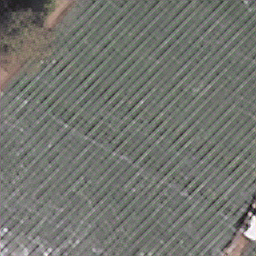

Showing: agricultural_agricultural00_10000.png


In [ ]:
from IPython.display import Image, display
import os

vis_dir = "/content/LDL/experiments/LDL_UCMerced_50k/visualization/10000"
sample = sorted(os.listdir(vis_dir))[0]  # pick first file
display(Image(filename=os.path.join(vis_dir, sample)))
print("Showing:", sample)


# Test LDL

In [ ]:
!PYTHONPATH="./:${PYTHONPATH}" CUDA_VISIBLE_DEVICES=0 \
python /content/LDL/basicsr/test.py -opt /content/LDL/options/test/LDL/test_LDL_Synthetic_x4.yml


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Disable distributed.
Path already exists. Rename it to /content/LDL/results/LDL_Synthetic_UCMerced_x4_archived_20251119_231754
2025-11-19 23:17:54,563 INFO: 
                ____                _       _____  ____
               / __ ) ____ _ _____ (_)_____/ ___/ / __ \
              / __  |/ __ `// ___// // ___/\__ \ / /_/ /
             / /_/ // /_/ /(__  )/ // /__ ___/ // _, _/
            /_____/ \__,_//____//_/ \___//____//_/ |_|
     ______                   __   __                 __      __
    / ____/____   ____   ____/ /  / /   __  __ _____ / /__   / /
   / / __ / __ \ / __ \ / __  /  / /   / / / // ___// //_/  / /
  / /_/ // /_/ // /_/ // /_/ /  / /___/ /_/ // /__ / /<    /_/
  \____/ \____/ \____/ \____/

Compute LPIPS on  UCMerced test set

In [ ]:
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.2 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import torch
import lpips
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"
loss_fn = lpips.LPIPS(net='alex').to(device)

hr_root = Path("/content/LDL/datasets/UCMerced/HR")
sr_root = Path("/content/LDL/results/LDL_Synthetic_UCMerced_x4/visualization/UCMerced")

valid_exts = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

# 1) Build HR map (keys without suffix)
def build_hr_map(root):
    mapping = {}
    for p in root.rglob("*"):
        if p.suffix.lower() not in valid_exts:
            continue
        cls = p.parent.name
        stem = p.stem
        key1 = stem
        key2 = f"{cls}_{stem}"
        mapping[key1] = p
        mapping[key2] = p
    return mapping

# 2) Build SR map (strip "_LDL_Synthetic_UCMerced_x4")
def build_sr_map(root):
    mapping = {}
    for p in root.rglob("*"):
        if p.suffix.lower() not in valid_exts:
            continue
        stem = p.stem
        clean_stem = stem.replace("_LDL_Synthetic_UCMerced_x4", "")
        mapping[clean_stem] = p
    return mapping

hr_map = build_hr_map(hr_root)
sr_map = build_sr_map(sr_root)

print("HR keys:", len(hr_map))
print("SR keys:", len(sr_map))

common = sorted(set(hr_map.keys()) & set(sr_map.keys()))
print("Matched image count:", len(common))

if len(common) == 0:
    print("No matches – printing sample keys:")
    print("HR:", list(hr_map.keys())[:20])
    print("SR:", list(sr_map.keys())[:20])

lpips_vals = []

for k in common:
    hr_path = str(hr_map[k])
    sr_path = str(sr_map[k])

    hr = cv2.imread(hr_path, cv2.IMREAD_COLOR)
    sr = cv2.imread(sr_path, cv2.IMREAD_COLOR)

    if hr is None or sr is None:
        continue

    hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    sr = cv2.cvtColor(sr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    h = min(hr.shape[0], sr.shape[0])
    w = min(hr.shape[1], sr.shape[1])
    hr = hr[:h, :w]
    sr = sr[:h, :w]

    hr_t = torch.from_numpy(hr).permute(2,0,1).unsqueeze(0).to(device)*2 - 1
    sr_t = torch.from_numpy(sr).permute(2,0,1).unsqueeze(0).to(device)*2 - 1

    with torch.no_grad():
        d = loss_fn(hr_t, sr_t).item()

    lpips_vals.append(d)

if lpips_vals:
    print("\nAverage LPIPS:", np.mean(lpips_vals))
else:
    print("\nNo LPIPS values computed.")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
HR keys: 4200
SR keys: 2100
Matched image count: 2100

Average LPIPS: 0.14521169067670903


# Train ESRGAN

In [ ]:
!cd /content/LDL
!PYTHONPATH="./:${PYTHONPATH}" CUDA_VISIBLE_DEVICES=0 \
python basicsr/train.py -opt options/train/LDL/train_ESRGAN_UCMerced_x4.yml


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Disable distributed.
Path already exists. Rename it to /content/LDL/experiments/ESRGAN_UCMerced_x4_archived_20251119_205521
Path already exists. Rename it to /content/LDL/tb_logger/ESRGAN_UCMerced_x4_archived_20251119_205521
2025-11-19 20:55:21,746 INFO: 
  name: ESRGAN_UCMerced_x4
  model_type: ESRGANModel
  scale: 4
  num_gpu: 1
  manual_seed: 0
  datasets:[
    train:[
      name: UCMercedTrain
      type: PairedImageDataset
      dataroot_gt: /content/LDL/datasets/UCMerced/train/HR
      dataroot_lq: /content/LDL/datasets/UCMerced/train/LR_x4
      io_backend:[
        type: disk
      ]
      gt_size: 128
      use_flip: True
      use_rot: True
      use_shuffle: True
      num_worker_per_gpu: 2
      batch_si

# *Test ESRGAN*

In [ ]:
!cd /content/LDL && PYTHONPATH="./:${PYTHONPATH}" CUDA_VISIBLE_DEVICES=0 \
python basicsr/test.py -opt options/test/LDL/test_ESRGAN_UCMerced_x4.yml


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Disable distributed.
Path already exists. Rename it to /content/LDL/results/ESRGAN_UCMerced_x4_archived_20251119_230620
2025-11-19 23:06:20,602 INFO: 
                ____                _       _____  ____
               / __ ) ____ _ _____ (_)_____/ ___/ / __ \
              / __  |/ __ `// ___// // ___/\__ \ / /_/ /
             / /_/ // /_/ /(__  )/ // /__ ___/ // _, _/
            /_____/ \__,_//____//_/ \___//____//_/ |_|
     ______                   __   __                 __      __
    / ____/____   ____   ____/ /  / /   __  __ _____ / /__   / /
   / / __ / __ \ / __ \ / __  /  / /   / / / // ___// //_/  / /
  / /_/ // /_/ // /_/ // /_/ /  / /___/ /_/ // /__ / /<    /_/
  \____/ \____/ \____/ \____/  /____

## Compare Results

In [ ]:
!pip install lpips

import os
import re
from pathlib import Path

import cv2
import numpy as np
import torch
import lpips
import pandas as pd


In [ ]:
# ====== EDIT HERE IF YOUR PATHS ARE DIFFERENT ======
LDL_LOG   = "/content/LDL/results/LDL_Synthetic_UCMerced_x4/test_LDL_Synthetic_UCMerced_x4_20251119_231754.log"
ESR_LOG   = "/content/LDL/results/ESRGAN_UCMerced_x4/test_ESRGAN_UCMerced_x4_20251119_230620.log"

HR_DIR        = "/content/LDL/datasets/UCMerced/HR"
LDL_SR_DIR    = "/content/LDL/results/LDL_Synthetic_UCMerced_x4/visualization/UCMerced"
ESR_SR_DIR    = "/content/LDL/results/ESRGAN_UCMerced_x4/visualization/UCMerced"

LDL_SUFFIX = "_LDL_Synthetic_UCMerced_x4"
ESR_SUFFIX = "_ESRGAN_UCMerced_x4"
# ================================================


In [ ]:
def parse_psnr_ssim_from_log(log_path):
    """
    Parse PSNR and SSIM from a BasicSR test.log file.
    Looks for lines like:
        # psnr: 26.4079
        # ssim: 0.7359
    """
    psnr_val, ssim_val = None, None
    with open(log_path, "r") as f:
        for line in f:
            if "psnr:" in line:
                m = re.search(r"psnr:\s*([0-9.]+)", line)
                if m:
                    psnr_val = float(m.group(1))
            if "ssim:" in line:
                m = re.search(r"ssim:\s*([0-9.]+)", line)
                if m:
                    ssim_val = float(m.group(1))
    return psnr_val, ssim_val

ldl_psnr, ldl_ssim = parse_psnr_ssim_from_log(LDL_LOG)
esr_psnr, esr_ssim = parse_psnr_ssim_from_log(ESR_LOG)

print("LDL-SR  -> PSNR:", ldl_psnr, " SSIM:", ldl_ssim)
print("ESRGAN  -> PSNR:", esr_psnr, " SSIM:", esr_ssim)


LDL-SR  -> PSNR: 26.2335  SSIM: 0.7336
ESRGAN  -> PSNR: 23.8825  SSIM: 0.6428


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
lpips_model = lpips.LPIPS(net='alex').to(device)
valid_exts = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

def build_hr_map(hr_root: Path):
    """
    Walk HR directory recursively and build key -> path mapping.
    Keys include variations like:
      stem
      class_stem
      HR_class_stem
    so we can match SR files like "harbor_harbor21_XXX_x4.png".
    """
    mapping = {}
    for p in hr_root.rglob("*"):
        if p.suffix.lower() not in valid_exts:
            continue
        cls = p.parent.name
        stem = p.stem
        mapping[stem] = p
        mapping[f"{cls}_{stem}"] = p
        mapping[f"HR_{cls}_{stem}"] = p
    return mapping

def build_sr_map(sr_root: Path, suffix: str):
    """
    Walk SR directory and build mapping:
      clean_stem (stem with suffix removed) -> path
    """
    mapping = {}
    for p in sr_root.rglob("*"):
        if p.suffix.lower() not in valid_exts:
            continue
        stem = p.stem
        clean_stem = stem.replace(suffix, "")
        mapping[clean_stem] = p
    return mapping

def compute_lpips(hr_dir, sr_dir, suffix):
    hr_root = Path(hr_dir)
    sr_root = Path(sr_dir)

    hr_map = build_hr_map(hr_root)
    sr_map = build_sr_map(sr_root, suffix)

    print(f"\n=== LPIPS for suffix {suffix} ===")
    print("HR keys:", len(hr_map), " SR keys:", len(sr_map))

    common = sorted(set(hr_map.keys()) & set(sr_map.keys()))
    print("Matched images:", len(common))

    vals = []

    for k in common:
        hr_path = str(hr_map[k])
        sr_path = str(sr_map[k])

        hr = cv2.imread(hr_path, cv2.IMREAD_COLOR)
        sr = cv2.imread(sr_path, cv2.IMREAD_COLOR)
        if hr is None or sr is None:
            continue

        hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        sr = cv2.cvtColor(sr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

        h = min(hr.shape[0], sr.shape[0])
        w = min(hr.shape[1], sr.shape[1])
        hr = hr[:h, :w]
        sr = sr[:h, :w]

        hr_t = torch.from_numpy(hr).permute(2,0,1).unsqueeze(0).to(device)*2 - 1
        sr_t = torch.from_numpy(sr).permute(2,0,1).unsqueeze(0).to(device)*2 - 1

        with torch.no_grad():
            d = lpips_model(hr_t, sr_t).item()
        vals.append(d)

    if vals:
        avg = float(np.mean(vals))
        print("Average LPIPS:", avg)
        return avg
    else:
        print("No LPIPS values computed.")
        return float("nan")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [ ]:
ldl_lpips = compute_lpips(HR_DIR, LDL_SR_DIR, LDL_SUFFIX)
esr_lpips = compute_lpips(HR_DIR, ESR_SR_DIR, ESR_SUFFIX)

print("\nFinal LPIPS:")
print("LDL-SR  :", ldl_lpips)
print("ESRGAN  :", esr_lpips)



=== LPIPS for suffix _LDL_Synthetic_UCMerced_x4 ===
HR keys: 6300  SR keys: 420
Matched images: 420
Average LPIPS: 0.14805578416479484

=== LPIPS for suffix _ESRGAN_UCMerced_x4 ===
HR keys: 6300  SR keys: 420
Matched images: 420
Average LPIPS: 0.2808463351357551

Final LPIPS:
LDL-SR  : 0.14805578416479484
ESRGAN  : 0.2808463351357551


In [ ]:
results = [
    {
        "Backbone": "RRDB",
        "Method": "ESRGAN (baseline)",
        "PSNR": esr_psnr,
        "SSIM": esr_ssim,
        "LPIPS": esr_lpips,
    },
    {
        "Backbone": "RRDB",
        "Method": "LDL-SR (ours)",
        "PSNR": ldl_psnr,
        "SSIM": ldl_ssim,
        "LPIPS": ldl_lpips,
    },
]

df = pd.DataFrame(results)
df_rounded = df.copy()
df_rounded["PSNR"]  = df_rounded["PSNR"].map(lambda x: f"{x:.2f}")
df_rounded["SSIM"]  = df_rounded["SSIM"].map(lambda x: f"{x:.4f}")
df_rounded["LPIPS"] = df_rounded["LPIPS"].map(lambda x: f"{x:.4f}")
df_rounded


,Backbone,Method,PSNR,SSIM,LPIPS
0,RRDB,ESRGAN (baseline),23.88,0.6428,0.2808
1,RRDB,LDL-SR (ours),26.23,0.7336,0.1481


In [ ]:
df_rounded.to_csv("/content/LDL/Table1_UCMerced_ESRGAN_vs_LDL.csv", index=False)
print("Saved Table 1 CSV to /content/LDL/Table1_UCMerced_ESRGAN_vs_LDL.csv")


Saved Table 1 CSV to /content/LDL/Table1_UCMerced_ESRGAN_vs_LDL.csv


All Results

In [ ]:
import os, re
from pathlib import Path

import cv2
import numpy as np
import torch
import lpips
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
ROOT = "/content/LDL"
LDL_LOG   = "/content/LDL/results/LDL_Synthetic_UCMerced_x4/test_LDL_Synthetic_UCMerced_x4_20251119_231754.log"
ESR_LOG   = "/content/LDL/results/ESRGAN_UCMerced_x4/test_ESRGAN_UCMerced_x4_20251119_230620.log"

HR_DIR        = "/content/LDL/datasets/UCMerced/HR"
LDL_SR_DIR    = "/content/LDL/results/LDL_Synthetic_UCMerced_x4/visualization/UCMerced"
ESR_SR_DIR    = "/content/LDL/results/ESRGAN_UCMerced_x4/visualization/UCMerced"

LDL_SUFFIX = "_LDL_Synthetic_UCMerced_x4"
ESR_SUFFIX = "_ESRGAN_UCMerced_x4"

Extract PSNR/SSIM

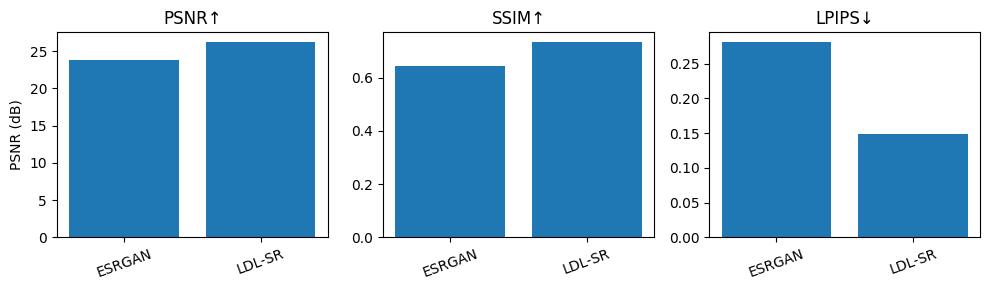

Saved metric plot to: /content/LDL/UCMerced_ESRGAN_vs_LDL_metrics.png


In [ ]:
models = ["ESRGAN", "LDL-SR"]
psnr_vals  = [esr_psnr,  ldl_psnr]
ssim_vals  = [esr_ssim,  ldl_ssim]
lpips_vals = [esr_lpips, ldl_lpips]

x = np.arange(len(models))

plt.figure(figsize=(10, 3))

# PSNR
plt.subplot(1, 3, 1)
plt.bar(x, psnr_vals)
plt.xticks(x, models, rotation=20)
plt.ylabel("PSNR (dB)")
plt.title("PSNR↑")

# SSIM
plt.subplot(1, 3, 2)
plt.bar(x, ssim_vals)
plt.xticks(x, models, rotation=20)
plt.title("SSIM↑")

# LPIPS
plt.subplot(1, 3, 3)
plt.bar(x, lpips_vals)
plt.xticks(x, models, rotation=20)
plt.title("LPIPS↓")

plt.tight_layout()
plt.savefig(f"{ROOT}/UCMerced_ESRGAN_vs_LDL_metrics.png", dpi=300)
plt.show()

print("Saved metric plot to:", f"{ROOT}/UCMerced_ESRGAN_vs_LDL_metrics.png")


In [ ]:
def find_hr_image(hr_dir, base_key):
    hr_root = Path(hr_dir)
    for p in hr_root.rglob("*"):
        if p.suffix.lower() not in valid_exts:
            continue
        stem = p.stem
        cls  = p.parent.name
        candidates = {stem, f"{cls}_{stem}", f"HR_{cls}_{stem}"}
        if base_key in candidates:
            return str(p)
    return None

def find_lr_image(lr_dir, hr_path):
    # assume LR has same relative folder & stem as HR
    hr_p = Path(hr_path)
    cls = hr_p.parent.name
    stem = hr_p.stem.replace("HR_", "")  # in case HR_ prefix exists
    # try same structure
    for ext in valid_exts:
        cand = Path(lr_dir) / cls / f"{stem}{ext}"
        if cand.exists():
            return str(cand)
    # fallback: search by stem
    for p in Path(lr_dir).rglob("*"):
        if p.suffix.lower() not in valid_exts:
            continue
        if p.stem.endswith(stem):
            return str(p)
    return None

def find_sr_image(sr_dir, base_key, suffix):
    sr_root = Path(sr_dir)
    for p in sr_root.rglob("*"):
        if p.suffix.lower() not in valid_exts:
            continue
        stem = p.stem
        if stem == base_key + suffix or stem.startswith(base_key):
            return str(p)
    return None


In [ ]:
def show_comparison(base_key, save_path=None):
    """
    base_key example: 'harbor_harbor03'
    """
    hr_path = find_hr_image(HR_DIR, base_key)
    if hr_path is None:
        print("HR not found for key:", base_key)
        return

    lr_path = find_lr_image(LR_DIR, hr_path)
    ldl_path = find_sr_image(LDL_SR_DIR, base_key, LDL_SUFFIX)
    esr_path = find_sr_image(ESR_SR_DIR, base_key, ESR_SUFFIX)

    print("HR :", hr_path)
    print("LR :", lr_path)
    print("LDL:", ldl_path)
    print("ESR:", esr_path)

    # load and convert to RGB
    def load_rgb(p):
        if p is None:
            return None
        img = cv2.imread(p, cv2.IMREAD_COLOR)
        if img is None:
            return None
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    hr  = load_rgb(hr_path)
    lr  = load_rgb(lr_path)
    ldl = load_rgb(ldl_path)
    esr = load_rgb(esr_path)

    imgs = [lr, esr, ldl, hr]
    titles = ["LR (input)", "ESRGAN", "LDL-SR", "HR (GT)"]

    plt.figure(figsize=(12, 3))
    for i, (img, title) in enumerate(zip(imgs, titles)):
        plt.subplot(1, 4, i+1)
        if img is not None:
            plt.imshow(img)
        plt.axis("off")
        plt.title(title)
    plt.suptitle(base_key, y=1.03)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved comparison to:", save_path)

    plt.show()


In [ ]:
files = sorted(os.listdir(LDL_SR_DIR))[60:120]
files


['denseresidential_denseresidential00_LDL_Synthetic_UCMerced_x4.png',
 'denseresidential_denseresidential02_LDL_Synthetic_UCMerced_x4.png',
 'denseresidential_denseresidential03_LDL_Synthetic_UCMerced_x4.png',
 'denseresidential_denseresidential11_LDL_Synthetic_UCMerced_x4.png',
 'denseresidential_denseresidential12_LDL_Synthetic_UCMerced_x4.png',
 'denseresidential_denseresidential14_LDL_Synthetic_UCMerced_x4.png',
 'denseresidential_denseresidential23_LDL_Synthetic_UCMerced_x4.png',
 'denseresidential_denseresidential32_LDL_Synthetic_UCMerced_x4.png',
 'denseresidential_denseresidential56_LDL_Synthetic_UCMerced_x4.png',
 'denseresidential_denseresidential68_LDL_Synthetic_UCMerced_x4.png',
 'denseresidential_denseresidential74_LDL_Synthetic_UCMerced_x4.png',
 'denseresidential_denseresidential76_LDL_Synthetic_UCMerced_x4.png',
 'denseresidential_denseresidential77_LDL_Synthetic_UCMerced_x4.png',
 'denseresidential_denseresidential79_LDL_Synthetic_UCMerced_x4.png',
 'denseresidential_d

HR : /content/LDL/datasets/UCMerced/HR/buildings_buildings04.png
LR : /content/LDL/datasets/UCMerced/LR_x4/buildings_buildings04.png
LDL: /content/LDL/results/LDL_Synthetic_UCMerced_x4/visualization/UCMerced/buildings_buildings04_LDL_Synthetic_UCMerced_x4.png
ESR: /content/LDL/results/ESRGAN_UCMerced_x4/visualization/UCMerced/buildings_buildings04_ESRGAN_UCMerced_x4.png
Saved comparison to: /content/LDL/compare_buildings_buildings04.png


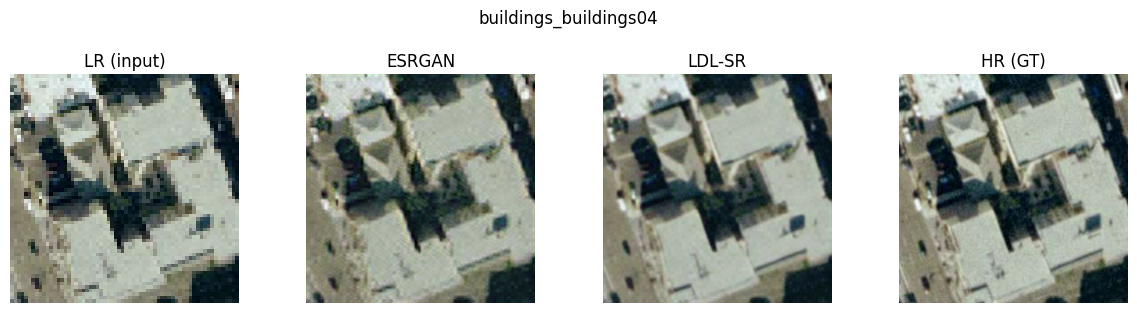

In [ ]:
base_key = "buildings_buildings04"  # change to any you like
save_fig = f"{ROOT}/compare_{base_key}.png"
show_comparison(base_key, save_path=save_fig)

HR : /content/LDL/datasets/UCMerced/HR/mediumresidential_mediumresidential80.png
LR : /content/LDL/datasets/UCMerced/LR_x4/mediumresidential_mediumresidential80.png
LDL: /content/LDL/results/LDL_Synthetic_UCMerced_x4/visualization/UCMerced/mediumresidential_mediumresidential80_LDL_Synthetic_UCMerced_x4.png
ESR: /content/LDL/results/ESRGAN_UCMerced_x4/visualization/UCMerced/mediumresidential_mediumresidential80_ESRGAN_UCMerced_x4.png
Saved comparison to: /content/LDL/compare_mediumresidential_mediumresidential80.png


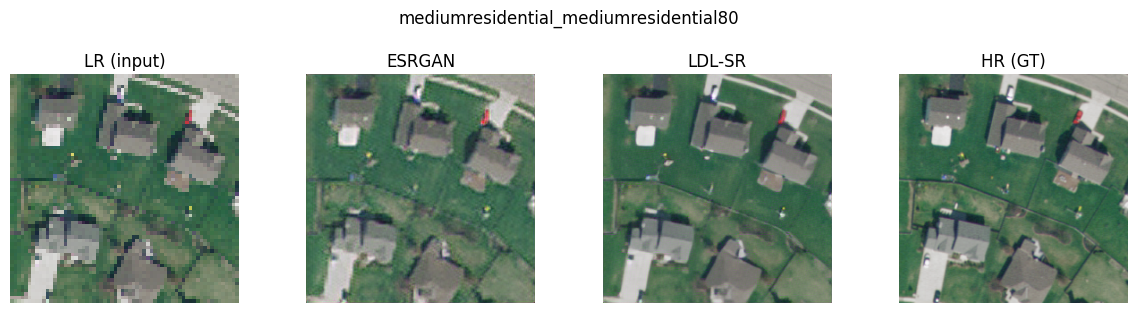

In [ ]:
base_key = "mediumresidential_mediumresidential80"#"buildings_buildings63"  # change to any you like
save_fig = f"{ROOT}/compare_{base_key}.png"
show_comparison(base_key, save_path=save_fig)

HR : /content/LDL/datasets/UCMerced/HR/harbor_harbor81.png
LR : /content/LDL/datasets/UCMerced/LR_x4/harbor_harbor81.png
LDL: /content/LDL/results/LDL_Synthetic_UCMerced_x4/visualization/UCMerced/harbor_harbor81_LDL_Synthetic_UCMerced_x4.png
ESR: /content/LDL/results/ESRGAN_UCMerced_x4/visualization/UCMerced/harbor_harbor81_ESRGAN_UCMerced_x4.png
Saved comparison to: /content/LDL/compare_harbor_harbor81.png


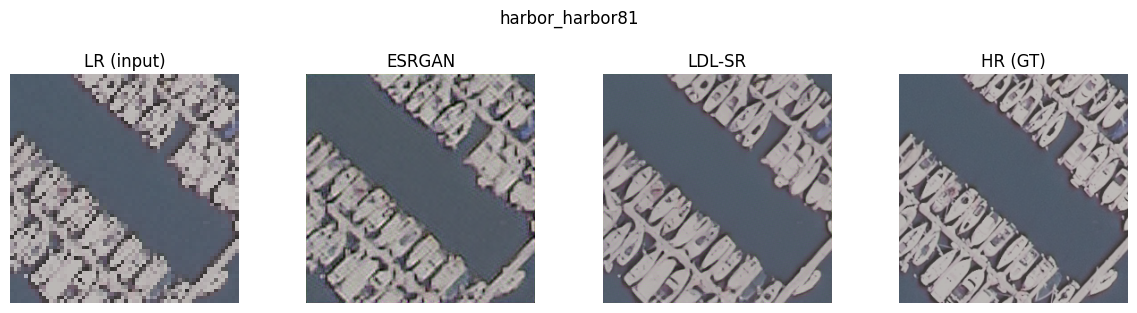

In [ ]:
base_key = "harbor_harbor81"
save_fig = f"{ROOT}/compare_{base_key}.png"
show_comparison(base_key, save_path=save_fig)

HR : /content/LDL/datasets/UCMerced/HR/denseresidential_denseresidential96.png
LR : /content/LDL/datasets/UCMerced/LR_x4/denseresidential_denseresidential96.png
LDL: /content/LDL/results/LDL_Synthetic_UCMerced_x4/visualization/UCMerced/denseresidential_denseresidential96_LDL_Synthetic_UCMerced_x4.png
ESR: /content/LDL/results/ESRGAN_UCMerced_x4/visualization/UCMerced/denseresidential_denseresidential96_ESRGAN_UCMerced_x4.png
Saved comparison to: /content/LDL/compare_denseresidential_denseresidential96.png


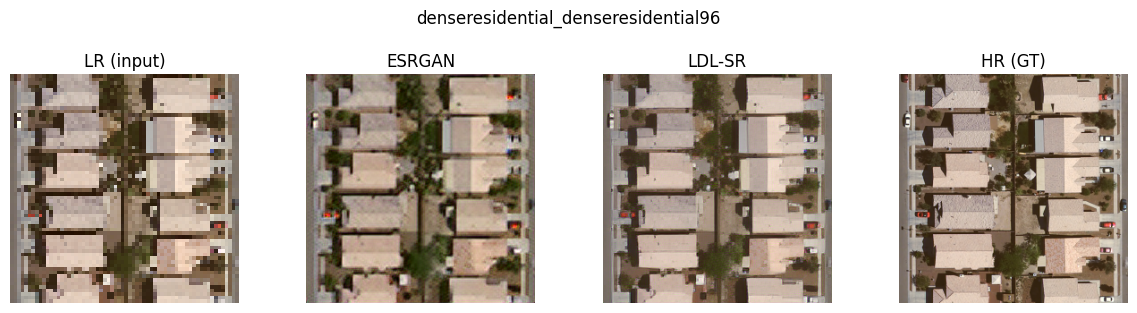

In [ ]:
base_key = "denseresidential_denseresidential96"  # change to any you like
save_fig = f"{ROOT}/compare_{base_key}.png"
show_comparison(base_key, save_path=save_fig)

In [ ]:
def show_difference_maps(base_key, save_path=None):
    hr_path = find_hr_image(HR_DIR, base_key)
    ldl_path = find_sr_image(LDL_SR_DIR, base_key, LDL_SUFFIX)
    esr_path = find_sr_image(ESR_SR_DIR, base_key, ESR_SUFFIX)

    if hr_path is None or ldl_path is None or esr_path is None:
        print("Missing images for key:", base_key)
        return

    def load_gray(p):
        img = cv2.imread(p, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
        # convert to grayscale (simple average)
        gray = img.mean(axis=2)
        return gray

    hr  = load_gray(hr_path)
    ldl = load_gray(ldl_path)
    esr = load_gray(esr_path)

    h = min(hr.shape[0], ldl.shape[0], esr.shape[0])
    w = min(hr.shape[1], ldl.shape[1], esr.shape[1])
    hr  = hr[:h,:w]
    ldl = ldl[:h,:w]
    esr = esr[:h,:w]

    diff_ldl = np.abs(hr - ldl)
    diff_esr = np.abs(hr - esr)

    plt.figure(figsize=(10, 3))
    plt.subplot(1, 3, 1)
    plt.imshow(hr, cmap="gray")
    plt.axis("off")
    plt.title("HR (gray)")

    plt.subplot(1, 3, 2)
    plt.imshow(diff_esr, cmap="inferno")
    plt.axis("off")
    plt.title("Error map: ESRGAN")

    plt.subplot(1, 3, 3)
    plt.imshow(diff_ldl, cmap="inferno")
    plt.axis("off")
    plt.title("Error map: LDL-SR")

    plt.suptitle(f"Error maps – {base_key}", y=1.03)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved diff map to:", save_path)
    plt.show()


Saved diff map to: /content/LDL/diffmaps_harbor_harbor03.png


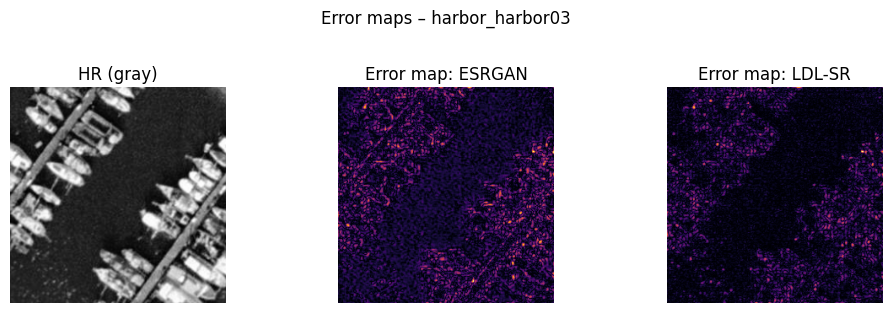

In [ ]:
show_difference_maps("harbor_harbor03", save_path=f"{ROOT}/diffmaps_harbor_harbor03.png")


In [ ]:
import os
from pathlib import Path
import numpy as np
import cv2
import torch
import lpips
import pandas as pd
from skimage.metrics import structural_similarity as ssim

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
lpips_model = lpips.LPIPS(net='alex').to(device)

valid_exts = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

def build_hr_map(hr_root: str):
    hr_root = Path(hr_root)
    mapping = {}
    for p in hr_root.rglob("*"):
        if p.suffix.lower() not in valid_exts:
            continue
        cls = p.parent.name
        stem = p.stem  # e.g. 'harbor21' or 'HR_harbor21'
        # multiple possible keys pointing to same HR
        mapping[stem] = p
        mapping[f"{cls}_{stem}"] = p
        mapping[f"HR_{cls}_{stem}"] = p
    return mapping

def build_sr_map(sr_root: str, suffix: str):
    sr_root = Path(sr_root)
    mapping = {}
    for p in sr_root.rglob("*"):
        if p.suffix.lower() not in valid_exts:
            continue
        stem = p.stem  # e.g. 'harbor_harbor03_LDL_Synthetic_UCMerced_x4'
        clean_stem = stem.replace(suffix, "")
        mapping[clean_stem] = p
    return mapping

def psnr_np(gt, pred):
    mse = np.mean((gt - pred) ** 2)
    if mse == 0:
        return 100.0
    return 10 * np.log10(1.0 / mse)  # assuming input in [0,1]


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [ ]:
hr_map   = build_hr_map(HR_DIR)
ldl_map  = build_sr_map(LDL_SR_DIR, LDL_SUFFIX)
esr_map  = build_sr_map(ESR_SR_DIR, ESR_SUFFIX)

common_keys = sorted(set(hr_map.keys()) & set(ldl_map.keys()) & set(esr_map.keys()))
print("Number of matched images:", len(common_keys))

records = []

for k in common_keys:
    hr_path  = str(hr_map[k])
    ldl_path = str(ldl_map[k])
    esr_path = str(esr_map[k])

    # Load images
    hr  = cv2.imread(hr_path, cv2.IMREAD_COLOR)
    ldl = cv2.imread(ldl_path, cv2.IMREAD_COLOR)
    esr = cv2.imread(esr_path, cv2.IMREAD_COLOR)

    if hr is None or ldl is None or esr is None:
        continue

    # Convert BGR->RGB, scale to [0,1]
    hr_rgb  = cv2.cvtColor(hr,  cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    ldl_rgb = cv2.cvtColor(ldl, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    esr_rgb = cv2.cvtColor(esr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    # Center crop to common size
    h = min(hr_rgb.shape[0], ldl_rgb.shape[0], esr_rgb.shape[0])
    w = min(hr_rgb.shape[1], ldl_rgb.shape[1], esr_rgb.shape[1])
    hr_rgb  = hr_rgb[:h, :w]
    ldl_rgb = ldl_rgb[:h, :w]
    esr_rgb = esr_rgb[:h, :w]

    # Y-channel (for PSNR/SSIM like in config)
    def to_y(img_rgb):
        # simple BT.601-ish: 0.299 R + 0.587 G + 0.114 B
        return (0.299*img_rgb[...,0] + 0.587*img_rgb[...,1] + 0.114*img_rgb[...,2])

    hr_y  = to_y(hr_rgb)
    ldl_y = to_y(ldl_rgb)
    esr_y = to_y(esr_rgb)

    # Compute PSNR/SSIM
    psnr_ldl = psnr_np(hr_y, ldl_y)
    psnr_esr = psnr_np(hr_y, esr_y)
    ssim_ldl = ssim(hr_y, ldl_y, data_range=1.0)
    ssim_esr = ssim(hr_y, esr_y, data_range=1.0)

    # LPIPS needs [-1,1] tensors
    def to_lpips_tensor(img_rgb):
        t = torch.from_numpy(img_rgb).permute(2,0,1).unsqueeze(0).to(device)
        return t*2 - 1

    with torch.no_grad():
        lpips_ldl = lpips_model(to_lpips_tensor(hr_rgb), to_lpips_tensor(ldl_rgb)).item()
        lpips_esr = lpips_model(to_lpips_tensor(hr_rgb), to_lpips_tensor(esr_rgb)).item()

    # Get class from key (first token before first "_")
    cls = k.split("_")[0]

    records.append({
        "key": k,
        "class": cls,
        "psnr_esr": psnr_esr,
        "psnr_ldl": psnr_ldl,
        "delta_psnr": psnr_ldl - psnr_esr,
        "ssim_esr": ssim_esr,
        "ssim_ldl": ssim_ldl,
        "delta_ssim": ssim_ldl - ssim_esr,
        "lpips_esr": lpips_esr,
        "lpips_ldl": lpips_ldl,
        "delta_lpips": lpips_esr - lpips_ldl,  # positive = LDL better (lower LPIPS)
    })

df = pd.DataFrame(records)
print(df.head())
print("Total rows:", len(df))

# Save for inspection if you like
df.to_csv("/content/LDL/UCMerced_per_image_metrics_ESRGAN_vs_LDL.csv", index=False)


Number of matched images: 420
                           key         class   psnr_esr   psnr_ldl  \
0  agricultural_agricultural02  agricultural  21.490641  21.242176   
1  agricultural_agricultural07  agricultural  16.674931  22.723259   
2  agricultural_agricultural18  agricultural  19.103245  23.066616   
3  agricultural_agricultural22  agricultural  17.689621  17.571423   
4  agricultural_agricultural25  agricultural  17.739693  21.362074   

   delta_psnr  ssim_esr  ssim_ldl  delta_ssim  lpips_esr  lpips_ldl  \
0   -0.248465  0.245136  0.209660   -0.035476   0.381049   0.356891   
1    6.048328  0.094007  0.780509    0.686502   0.395156   0.125529   
2    3.963371  0.180046  0.833225    0.653180   0.711885   0.054003   
3   -0.118198  0.525455  0.511919   -0.013536   0.329651   0.242731   
4    3.622381  0.193718  0.803238    0.609520   0.689505   0.053783   

   delta_lpips  
0     0.024158  
1     0.269627  
2     0.657882  
3     0.086920  
4     0.635722  
Total rows: 420


In [ ]:
top_gain = df.sort_values("delta_psnr", ascending=False).head(10)
top_gain[["key", "class", "psnr_esr", "psnr_ldl", "delta_psnr",
          "lpips_esr", "lpips_ldl", "delta_lpips"]]


,key,class,psnr_esr,psnr_ldl,delta_psnr,lpips_esr,lpips_ldl,delta_lpips
13,agricultural_agricultural70,agricultural,16.144762,25.720751,9.575989,0.692084,0.045900,0.646184
14,agricultural_agricultural72,agricultural,17.313320,26.756573,9.443253,0.695384,0.051122,0.644262
269,uc_beach_beach84,uc,26.074360,34.386097,8.311737,0.126131,0.053498,0.072633
10,agricultural_agricultural57,agricultural,25.927973,33.297474,7.369501,0.259184,0.051908,0.207276
395,uc_overpass_overpass95,uc,20.022282,27.041016,7.018734,0.460496,0.056897,0.403598
167,runway_runway32,runway,21.174721,27.613358,6.438637,0.330358,0.083381,0.246977
161,runway_runway01,runway,23.802900,30.239420,6.436520,0.297920,0.051611,0.246309
1,agricultural_agricultural07,agricultural,16.674931,22.723259,6.048328,0.395156,0.125529,0.269627
168,runway_runway37,runway,20.534119,26.556456,6.022337,0.366577,0.090723,0.275854
166,runway_runway31,runway,21.458092,27.363232,5.905140,0.341669,0.106288,0.235382


In [ ]:
# sort by delta_psnr, take median row (not too easy, not too extreme)
df_sorted = df.sort_values("delta_psnr")
mid_idx = len(df_sorted) // 2
mid_case = df_sorted.iloc[mid_idx]
mid_case

,341
key,uc_golfcourse_golfcourse59
class,uc
psnr_esr,30.63673
psnr_ldl,32.851631
delta_psnr,2.214901
ssim_esr,0.799534
ssim_ldl,0.841151
delta_ssim,0.041616
lpips_esr,0.157468
lpips_ldl,0.130889


In [ ]:
worse = df[df["delta_psnr"] < 0].sort_values("delta_psnr").head(10)
worse[["key", "class", "psnr_esr", "psnr_ldl", "delta_psnr",
       "lpips_esr", "lpips_ldl", "delta_lpips"]]


,key,class,psnr_esr,psnr_ldl,delta_psnr,lpips_esr,lpips_ldl,delta_lpips
15,agricultural_agricultural77,agricultural,17.947870,16.504694,-1.443176,0.274704,0.122366,0.152338
287,uc_chaparral_chaparral66,uc,18.740980,17.992832,-0.748148,0.533080,0.265516,0.267564
11,agricultural_agricultural65,agricultural,24.179062,23.451387,-0.727674,0.233415,0.182971,0.050444
19,agricultural_agricultural96,agricultural,22.096470,21.597254,-0.499216,0.493557,0.421099,0.072458
0,agricultural_agricultural02,agricultural,21.490641,21.242176,-0.248465,0.381049,0.356891,0.024158
295,uc_forest_forest11,uc,26.719389,26.537247,-0.182142,0.350033,0.273429,0.076604
298,uc_forest_forest43,uc,23.026323,22.862833,-0.163490,0.485710,0.316632,0.169078
296,uc_forest_forest13,uc,26.511841,26.370108,-0.141733,0.342500,0.285718,0.056782
3,agricultural_agricultural22,agricultural,17.689621,17.571423,-0.118198,0.329651,0.242731,0.086920
294,uc_forest_forest10,uc,28.545345,28.455484,-0.089861,0.300475,0.249771,0.050704


In [ ]:
# Example: take 3 very good improvement cases
selected_keys = top_gain["key"].tolist()
selected_keys


['agricultural_agricultural70',
 'agricultural_agricultural72',
 'uc_beach_beach84',
 'agricultural_agricultural57',
 'uc_overpass_overpass95',
 'runway_runway32',
 'runway_runway01',
 'agricultural_agricultural07',
 'runway_runway37',
 'runway_runway31']

In [ ]:
for k in selected_keys:
    fig_path = f"/content/LDL/compare_{k}.png"
    show_comparison(k, save_path=fig_path)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
worse_selected_keys = worse["key"].tolist()
worse_selected_keys

['agricultural_agricultural77',
 'uc_chaparral_chaparral66',
 'agricultural_agricultural65',
 'agricultural_agricultural96',
 'agricultural_agricultural02',
 'uc_forest_forest11',
 'uc_forest_forest43',
 'uc_forest_forest13',
 'agricultural_agricultural22',
 'uc_forest_forest10']

In [ ]:
for k in worse_selected_keys:
    fig_path = f"/content/LDL/compare_{k}.png"
    show_comparison(k, save_path=fig_path)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import shutil
import os

zip_path = "/content/LDL/experiments/ESRGAN_UCMerced_x4/visualization/Archive.zip"
output_folder = "/content/LDL/experiments/ESRGAN_UCMerced_x4/visualization/"

os.makedirs(output_folder, exist_ok=True)
shutil.unpack_archive(zip_path, output_folder)

print("✔ Unzip completed using shutil!")


✔ Unzip completed using shutil!


In [ ]:
import shutil

folder_path = "/content/LDL/experiments/ESRGAN_UCMerced_x4/visualization/__MACOSX"

# Delete the entire folder and everything inside it
shutil.rmtree(folder_path, ignore_errors=True)

print("✔ Folder and all contents deleted:", folder_path)


✔ Folder and all contents deleted: /content/LDL/experiments/ESRGAN_UCMerced_x4/visualization/__MACOSX
